In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [32]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [29]:
data = load_diabetes()

In [30]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [31]:
x = data.data
y = data.target

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [34]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [35]:
y_pred = lr.predict(x_test)

In [36]:
r2_score(y_test,y_pred)

0.4526027629719195

In [49]:
from sklearn.linear_model import Ridge

r = Ridge(alpha=0.01,fit_intercept=True)
r.fit(x_train,y_train)

Ridge(alpha=0.01)

In [50]:
y_pred = r.predict(x_test)

In [51]:
r2_score(y_test,y_pred)

0.4559819504579109

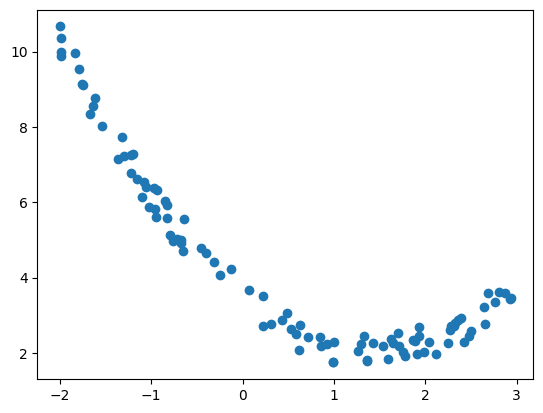

In [52]:
m = 100
x1= 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.rand(m,1)

plt.scatter(x1,x2)
plt.show()

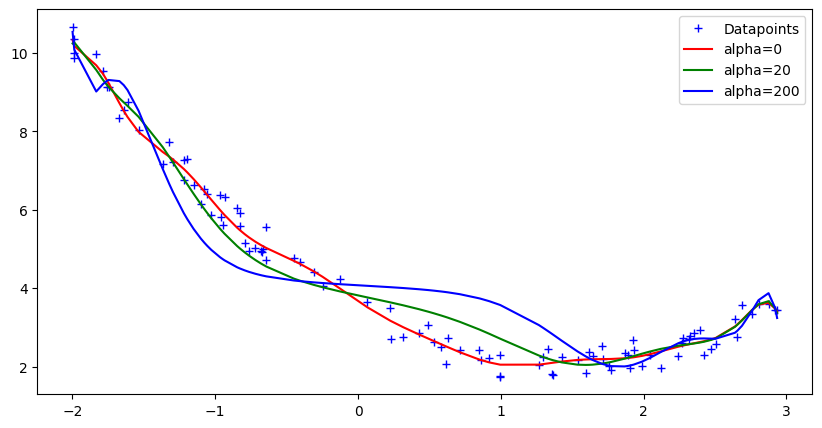

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_pred_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])

    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 5))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    pred = get_pred_ridge(x1, x2, alpha)

    plt.plot(
        sorted(x1[:, 0]),
        pred[np.argsort(x1[:, 0])],
        c,
        label=f'alpha={alpha}'
    )

plt.legend()
plt.show()